## Project Description 
The Goal of this Project is to compute the global minimum variance (GMV) portfolio for the top 400 stocks of the S&P500 over the course of 26 weeks. Due the sample covariance matrix being singular we are not able to use this our calculations from portfolio theory where the inverse of this matrix is needed. To deal with this issue we will create a single factor market model for the covariance matrix such that is invertible. Then proceed with the calculations for the GMV holding vector: $h_C$, portfolio variance: $\sigma^2_C$, standard deviation: $\sigma_C$, beta vector: $\beta_C$, and expected returns: $f_C$. Note that all reported values are represented as annualized absolute quantities. 

## Import Necessary Libraries

In [28]:
import numpy as np # Linear Algebra
import requests, pandas as pd # Data Manipulation
import yfinance as yf # Stock Data
from io import StringIO # Web Scraping
import matplotlib.pyplot as plt # Plotting
from matplotlib.ticker import PercentFormatter # Plotting Add-On 

## Web Scrape for Stock Tickers
The first challenge this project faces is gathering the tickers associated with all the stocks in the S&P500. this can be done using the official Wikipedia API to request structured data directly from the server. This involves setting up the request by setting the enpoint for the API, then parsing through the page that includes the list of S&P500 companies and requesting the test of the article. Then to bypass the restrictions, we set a user agent to give the script an identity. The request then fetches the content as a JSON object and extracts the table via the pandas and StringIO libraries. The final step is to extract the tickers from the table and store them as a list. 

Attachehed here is a reference link to the video for the code - https://www.youtube.com/watch?v=9gsn_9lh6uk

In [2]:
# Define wikipedia API endpoint 
API = 'https://en.wikipedia.org/w/api.php'

# Parameters to request the 'List of S&P 500 companies' page parsed as JSON
params = {
    'action': 'parse',
    'page': 'List_of_S&P_500_companies', 
    'prop': 'text', 
    'format': 'json'
}

# Identity header to prevent the API from blocking the request
headers = {'User-Agent': 'sp500-ticker-tutorial/1.0'}
r = requests.get(API, params = params, headers = headers)
html = r.json()['parse']['text']['*']

# Read the HTML table into a DataFrame and extract the symbol column as a list
df = pd.read_html(StringIO(html))[0]
tickers = df['Symbol'].astype(str).tolist()

## Data Manipulation and Organization
Now that we have the tickers of all the assets help in the S&P500 we can begin to clean and organize. The first step is to remove ticker that include "." and replace them with "-" for the yfinance API. Then we can define the date range for our dataset and download the closing price for each stock using a weekly interval. Now that we have the data we need to consider how we should order each stock to dtermine the top 400. The first thing that comes to mind is market cap. The market cap of a stock is just its current closing prices times the number of outstanding shares. To get the current number of outstannding shares we grab the info from each individual ticker within a loop and store the results ticker and market cap in a dictionary. Once that dictionary has been filled out we can sort by the market cap and extract the first 400 elements from the dataframe and retrieve the top 400 stocks weighted by market cap. Now that we have the new list we can redownload the data for the sorted list of stock tickers. This portion of code finishes with a final check to ensure that no values are missing from the dataset. 

One Note about the assumptions of this model is the calculation involving the outstanding shares. When this is grabbed using the stock.info.get() function from yahoo finance returns the current number of outstanding shares. This does not match up with the timeline that the downloaded data is from. Because we are unable to grab the number of outstanding shares from a previous date we multiply the current shares by the last closing price value available within the dataset to retrieve the estimated market cap. 

In [3]:
# Remove unusable tickers for yfinance api 
for bad in ["BRK.B", "BF.B"]:
    if bad in tickers:
        tickers.remove(bad)

# add usable tickers
tickers = tickers + ["BRK-B","BF-B"]

# Define Date Range
start_date = "2025-05-26"
end_date = "2025-11-28"

# Download raw data for all tickers 
data = yf.download(tickers, start=start_date, end=end_date, interval="1wk")
closing_prices = data['Close']

# Download raw data for S&P500 benchmark 
spy_data = yf.download("SPY", start=start_date, end=end_date, interval="1wk")
spy_prices = spy_data['Close']

# initialize storage for dictionary
results = [] 

# loop through each ticker 
for ticker in tickers:
    try:
        # grab the most recent price and the number of outstanding shares
        last_price = closing_prices[ticker].dropna().iloc[-1] 
        stock = yf.Ticker(ticker)
        shares = stock.info.get('sharesOutstanding')

        if shares != None:
            # Compute market cap for individual tickers
            m_cap = last_price * shares
            # append ticker and associated market cap data to dictionary
            results.append({'Ticker': ticker, 'MarketCap': m_cap})
            
    except Exception: 
        continue 

# convert to dataframe for easier use
dataframe = pd.DataFrame(results)
# sort from largest to smallest and grab top 400 elements
top_400 = dataframe.sort_values(by='MarketCap', ascending=False).head(400)

# store top 400 tickers in list
top_400_tickers = top_400["Ticker"].tolist() 
# Download data again but this time for top 400 tickers
top_400_data = yf.download(top_400_tickers, start= start_date, end = end_date, interval = "1wk")
top_400_close = top_400_data["Close"]

# Check for missing values in data 
missing_counts = top_400_close.isna().sum().sum()
if missing_counts == 0:
    print("The Data contains no missing values")
else: 
    print(f"The Data contains {missing_counts} missing values")

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  503 of 503 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  400 of 400 completed


The Data contains no missing values


## Constructing the Sample Covariance Matrix
Using the now clean data we can continue with the computations. The first act of business is to create the returns matrix by taking the weekly percent changes for our dataset. Taking the transpose we are now able to create the proper dimensions (400 x 26). Then subtract the weekly risk fre rate from a 6-month treasury bond and mean to create the de-meaned excess returns matrix $Y$. This is then used to create the sample covariance matrix via the formula: $S = YY^T/n$ where $n=26$ is the number of observations.

In [5]:
# Create the returns matrix and take the transpose for required shape
# .dropna() gets rid of the empty row created from .pct_change()
returns = top_400_close.pct_change().dropna() 
returns_matrix = returns.T.to_numpy()

# create return vector for benchmark 
spy_returns = spy_prices.pct_change().dropna()

# 6-month treasury yield rates
risk_free_rate = 0.0375 
weekly_RFR = risk_free_rate/52 

# Excess Returns Formula
excess_returns_matrix = returns_matrix - weekly_RFR 
spy_excess_returns = spy_returns - weekly_RFR

# axis=1 takes mean of each row and creates a column vector of each stocks mean 
# keepdims=True enable matrix subtraction by copying each collumn to match the matrix being worked on  
excess_returns_mean_vector = excess_returns_matrix.mean(axis=1, keepdims= True)

# Creating the p x n de-meaned excess returns matrix Y
Y = excess_returns_matrix - excess_returns_mean_vector

# calculate sample covariance matrix S
# Since n (26) < p (400), S is singular (non-invertible)
S = (Y @ Y.T) / 26 

## Single Factor Market Model for Covariance Matrix
Since there are only 26 weeks of data, the rank of the covariance matrix $S$ is at most $26$ implying that it is singular and therefore not invertible. To deal with this we can create a single factor market model that acts as a shrinkage estimator for the true coviance matrix via the formula: $\Sigma = (\lambda^2- \ell^2)hh^T + (n/p)\ell^2 I$ where $n=26$ is the number of observations, $p=400$ is the number of assets, $\lambda^2$ is the leading eiganvalue of $S$, $h$ is its corresponding unit eigenvector, $I$ is the identity matrix, and $\ell^2 = (tr(S)-\lambda^2)/(n-1)$ is the average of the non-zero eigenvalues that are less than $\lambda^2$. 

Using the new single factor market model as an estimator for the true covariance matrix we are now able to take the inverse necessary for computations in constructing the global minimum variance portfolio. $\Sigma$ acts as a regularization technique by adding the term $(n/p)\ell^2 I$ we are preforming a spectral shift. What this does is takes the origional covariance matrix $S$ with 374 eigenvalues of zero and shifts them upwards by at least $(n/p)\ell^2$. This in turn ensures that the determinant is strictly positive and therefore invertible. 

Furthermore, the leading eigenvector $h$ is preserved in this transformation. Since $h$ is an eigenvector of both the rank-1 matrix $hh^T$ and the identity matrix $I$, it remains the leading eigenvector of $\Sigma$. This ensures that our model accurately captures the primary direction of market systematic risk while providing the numerical stability required for computations. Mathematically, because $\Sigma$ is a linear combination of the outerproduct and identity matrix, the principle direction remains unchanges. The model cleans out the noise in the null space of $S$ without distorting the primary market factor captured by $h$.  

In [6]:
# compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(S)

# find leading eigenvalue (Market Factor)
lambda_sq = np.real(eigenvalues[-1])
h = np.real(eigenvectors[:,-1]).reshape(-1,1)

# subtract the leading eigenvalue from the total variance (Trace)
# Distribute the remainder across the other n-1 degrees of freedom
trace_S = np.real(np.trace(S))
ell_sq = (trace_S - lambda_sq) / (25)

# Assemble Single-Factor Model Covariance Matrix
term1 = (lambda_sq - ell_sq) * (h @ h.T)
term2 = (26/400) * ell_sq * np.eye(400)
Sigma = np.real(term1 + term2)

# grab eigenval and eiganvector from Sigma
evals_Sigma, evecs_Sigma = np.linalg.eigh(Sigma)
h_Sigma = evecs_Sigma[:, -1].reshape(-1, 1)

# Check if they are pointing in opposite directions
if np.dot(h.T, h_Sigma) < 0:
    h_Sigma = -h_Sigma

#Compute MSE to check eigan vectors are the same
mse_eiganvector = np.mean((h - h_Sigma)**2)

## GMV & Benchmark Portfolio Computations
Using $\Sigma$ in place of $S$ we can now preform the following calculations to obtain the holding vector of the global minimum variance portfolio $h_C = \Sigma^{-1}e/e^T\Sigma e$ where $e$ is the vector of ones. Next we compute the variance of the portfolio $\sigma^2_C = h^T_C \Sigma h_C$ and its standard deviation by taking the squareroot of the variance. Then we can compute the Beta vector of the portfolio via $\beta_C = \Sigma h_C/ \sigma^2_C$. Now we are able compute is the expected excess return of the portfolio $f_C=h^T_C \mu$ where $\mu$ is the excess returns mean vector. Furthermore, we want to capture the individual variance among each stock. This is captured on the diagonal of the covariance matrix $\Sigma$ but displaying all 400 variances would be overwhelming. instead we capture the mean and minimum from the individual stock variances and use that for comparison against the constructed portfolio. The last few lines of this code block also calculate the statistics for the S&P500 index to use as a benchmark for the GMV portfolio

In [15]:
# e is vector of ones used to enforce constraints thast weights sum to 1
e = np.ones(400) # characteristic for GMV portfolio
Sigma_inverse = np.linalg.inv(Sigma) 

# Compute Global Minimum Variance (GMV) weights (h_C)
holdings_C = (Sigma_inverse @ e) / (e.T @ Sigma_inverse @ e)

# Calculate the variance 
Variance_C = (holdings_C.T @ Sigma @ holdings_C)
annual_Variance_C = Variance_C * 52 

# Compute Standard Deviation 
std_pfolo_C = np.sqrt(Variance_C)
annualized_std_pfolio_C = std_pfolo_C * np.sqrt(52)

# Compute expected excess returns
expected_excess_returns_C = holdings_C.T @ excess_returns_mean_vector
annualized_expected_excess_returns_C = expected_excess_returns_C * 52

# Calculate Beta WRT Pfolio C
Beta_C = (Sigma @ holdings_C) / Variance_C

#Compute Variance for indivdual stocks 
# store the diagonal elements in array 
individual_variance = np.diag(Sigma)
annual_individual_variance = individual_variance * 52
mean_variance = annual_individual_variance.mean()

#lowest variance 
index_low = np.argmin(annual_individual_variance)

# Benchmark Metrics 
spy_annual_variance = spy_excess_returns.var() * 52
spy_annual_std = np.sqrt(spy_annual_variance)
spy_annual_expected_return = spy_excess_returns.mean() * 52

# Calculate GMV Sharpe Ratio
gmv_sharpe = annualized_expected_excess_returns_C.item() / annualized_std_pfolio_C

# Calculate SPY Sharpe Ratio
spy_sharpe = spy_annual_expected_return.iloc[0] / spy_annual_std.iloc[0]

## Analysis and Visualization 
Included below are three different visualizations inclduing a scree plot of the eigenvalue distribution, a histogram of the portfolio weights, and a direct comparison of the cumulative returns of the portfolio and the benchmark. 

The scree plot illustrate the decay of eigenvalues from the sample covariance matrix $S$. The spike at the leading principal component represents the market factor AKA the systematic risk shared by all 400 stocks. The rapid decline justifies the use of the single factor model by isolating the leading eigenvalue $\lambda^2$ and averaging he noise into $\ell^2$. 

The histogram plot shows the distribution of the weights from the holding vector $h_C$. This shows how the capital in the portfolio is allocated across the top 400 stocks. Noticing that that most of the spread is near the center of the distribution. This confirms that the portfolio is not concentrating specifically on a few stocks and is throughly diversified across all of the assets to reduce the risk. 

The final plot is a direct comparison between the GMV portfolio and the benchmark, tracking the growth of $1 over the 26 week time frame. Notice how the GMV exhibits much smaller swings during market dips. This helps to show that while we are achieving lower returns compared to the benchmark, we are able to minimize the volatility of the portfolio while still achieving positive excess returns. 

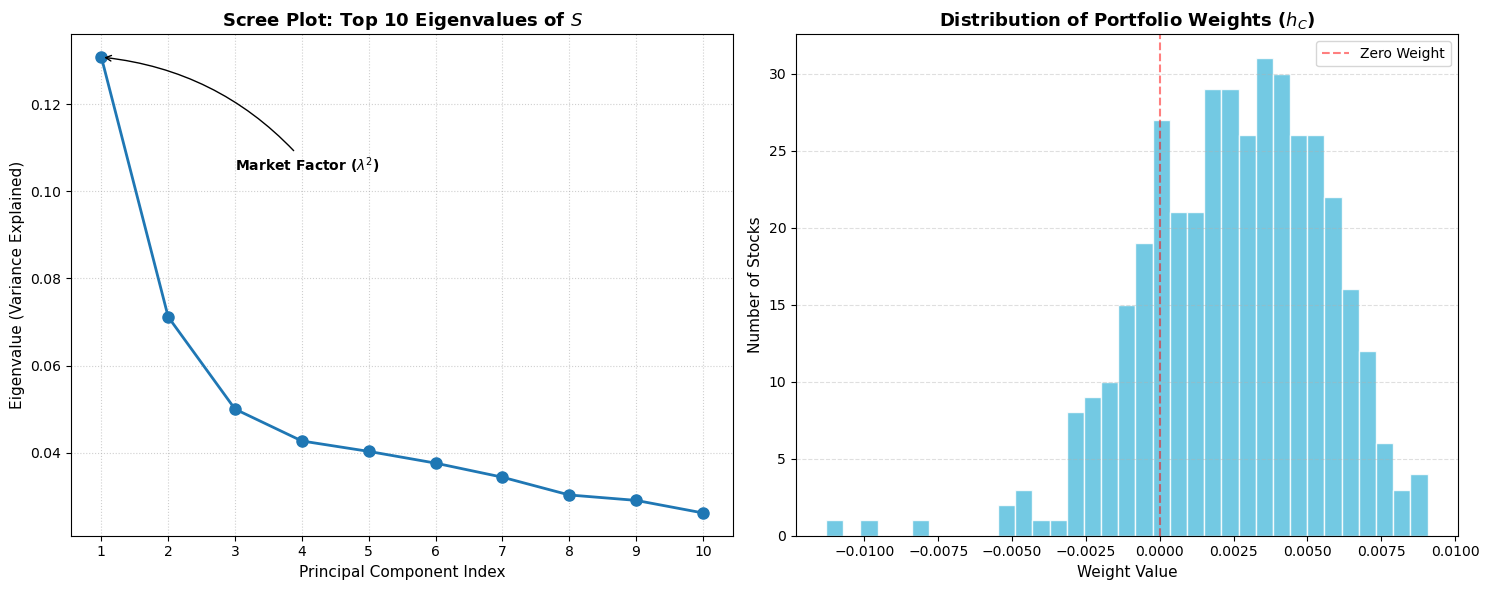

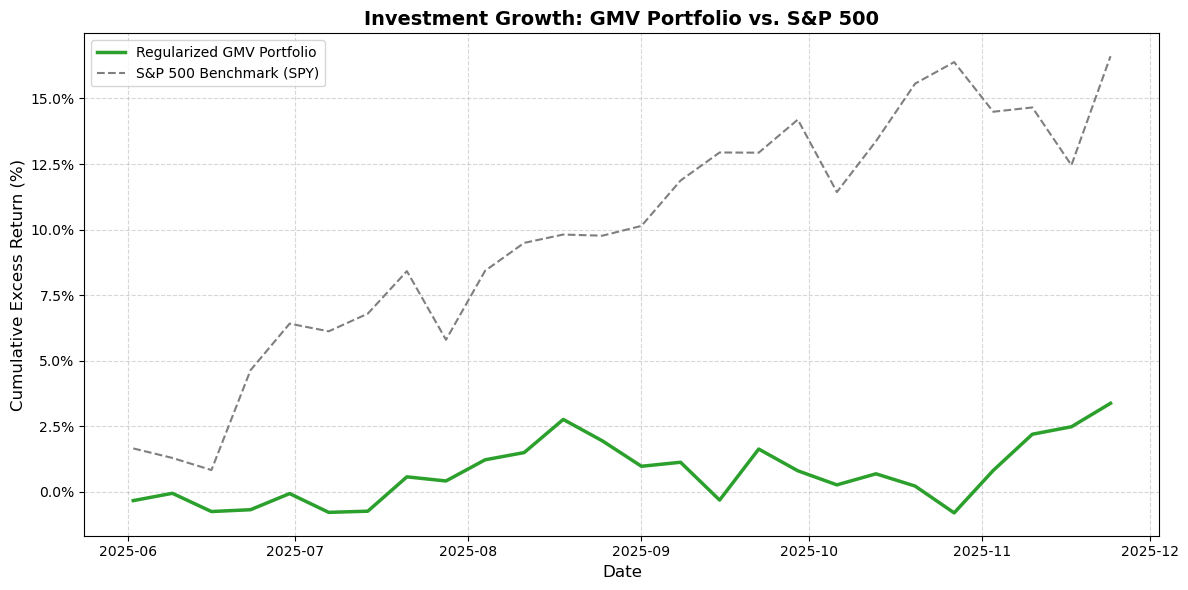

In [31]:
# We use subplots to keep the analysis together
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1 - Scree Plot (Eigenvalue Decay)
sorted_evals = np.sort(eigenvalues)[::-1]
ax1.plot(range(1, 11), sorted_evals[:10], marker='o', linestyle='-', color='#1f77b4', linewidth=2, markersize=8)
ax1.set_title('Scree Plot: Top 10 Eigenvalues of $S$', fontsize=13, fontweight='bold')
ax1.set_xlabel('Principal Component Index', fontsize=11)
ax1.set_ylabel('Eigenvalue (Variance Explained)', fontsize=11)
ax1.set_xticks(range(1, 11))
ax1.grid(True, linestyle=':', alpha=0.6)

# Highlight the Market Factor
ax1.annotate(r'Market Factor ($\lambda^2$)', 
             xy=(1, sorted_evals[0]), 
             xytext=(3, sorted_evals[0] * 0.8),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2', color='black'),
             fontsize=10, fontweight='bold')

# Plot 2: Portfolio Weight Distribution
ax2.hist(holdings_C.flatten(), bins=35, color='#5bc0de', edgecolor='white', alpha=0.85)
ax2.set_title('Distribution of Portfolio Weights ($h_C$)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Weight Value', fontsize=11)
ax2.set_ylabel('Number of Stocks', fontsize=11)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.axvline(0, color='red', linestyle='--', alpha=0.5, label='Zero Weight')
ax2.legend()
plt.tight_layout()
plt.show()

# plot 2 - Cumulative Performance
# Calculate the growth of $1 correctly
portfolio_weekly_returns = returns @ holdings_C.flatten()

# compute cumulative returns 
gmv_cumulative = (1 + portfolio_weekly_returns).cumprod() - 1
spy_cumulative = (1 + spy_returns.squeeze()).cumprod() - 1

fig2, ax3 = plt.subplots(figsize=(12, 6))
ax3.plot(gmv_cumulative.index, gmv_cumulative.values, label='Regularized GMV Portfolio', color='#2ca02c', linewidth=2.5)
ax3.plot(spy_cumulative.index, spy_cumulative.values, label='S&P 500 Benchmark (SPY)', color='#7f7f7f', linestyle='--', linewidth=1.5)

ax3.set_title('Investment Growth: GMV Portfolio vs. S&P 500', fontsize=14, fontweight='bold')
ax3.set_xlabel('Date', fontsize=12)
ax3.set_ylabel('Cumulative Excess Return (%)', fontsize=12)
ax3.yaxis.set_major_formatter(PercentFormatter(1.0)) # Formats 0.1 as 10%
ax3.legend(loc='upper left', frameon=True)
ax3.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Results and Conclusion
The final course of action is to now oberserve and compare the results from our model. As observed, the constructed portfolio resulted in a significant risk reduction. The GMV portfolio has an annualized variance of $0.00048$, which compares well against the mean of the individuals stocks variance of $0.0901$ and the lowest individual stock variance of $0.076$. This significant drop empirically provides evidence that the optimization process is working as theoretically intended to reduce risk. 

Looking at the model stability, the mean squarred error (MSE) for the leading eigenvector of the sample covariance matrix and the factor covariancxe matrix is $6.36e^{-34}$ which is essentially zero. This demonstrates that the primary market signal is not being distrorted. Additionally, we can note that the portfolio beta vector identically replicates the one vector $e$ providing a sanity check and further confirming that the variance has been minimized. 

The final point of discussion for this project is the comparison between the sharpe ratio of the GMV portfolio and the benchmark. As seen, the benchmark produces a sharpe ratio of $2.39$ which is significantly higher than our GMV sharpe ratio of $1.42$ helping indicate their is a tradeoff happening between reduced volatility and greater returns. Therefore we can infer that the risks and returns of a portfolio are subject to investor preferences and their tolerance for risk. 

All together, the results demonstrate that spectral regularization via a single market factor is a robust method for high-dimensional portfolio optimization when the number of assets greatly exceeds the number of observations. 

In [33]:
print("------ INPUTS ------")
print(f"Annual Risk-Free Rate: {risk_free_rate:.4f}")

print("\n------ MATRICES ------")
print(f"Excess Return Matrix Shape: {returns_matrix.shape}")
print(f"Sample Covariance Matrix Shape: {S.shape}")
print(f"Factor Model Matrix Shape: {Sigma.shape}")

print("\n------EIGENVECTOR ------")
print(f"Eigenvector Dimension: {h.shape}")
print(f"MSE (Leading Eigenvector): {mse_eiganvector:.6f}")

print("\n------ GMV PORTFOLIO  ------")
print(f"Total Holdings Sum: {sum(holdings_C):.4f}")
print(f"Variance: {annual_Variance_C:.6f}")
print(f"Std Dev: {annualized_std_pfolio_C:.6f}")
print(f"Beta: {Beta_C.mean():.4f}")
print(f"Expected Excess Return: {annualized_expected_excess_returns_C[0]:.6f}")
print(f"Sharpe Ratio: {gmv_sharpe:.4f}")

print("\n------ INDIVIDUAL STOCKS ------")
print(f"Mean Variance: {mean_variance:.6f}")
print(f"Lowest Variance: {annual_individual_variance[index_low]:.6f}")

print("\n------ BENCHMARK (SPY) ------")
print(f"Variance: {spy_annual_variance.iloc[0]:.6f}")
print(f"Std Dev: {spy_annual_std.iloc[0]:.6f}")
print(f"Expected Excess Return: {spy_annual_expected_return.iloc[0]:.6f}")
print(f"Sharpe Ratio: {spy_sharpe:.4f}")

------ INPUTS ------
Annual Risk-Free Rate: 0.0375

------ MATRICES ------
Excess Return Matrix Shape: (400, 26)
Sample Covariance Matrix Shape: (400, 400)
Factor Model Matrix Shape: (400, 400)

------EIGENVECTOR ------
Eigenvector Dimension: (400, 1)
MSE (Leading Eigenvector): 0.000000

------ GMV PORTFOLIO  ------
Total Holdings Sum: 1.0000
Variance: 0.000478
Std Dev: 0.021860
Beta: 1.0000
Expected Excess Return: 0.030964
Sharpe Ratio: 1.4165

------ INDIVIDUAL STOCKS ------
Mean Variance: 0.090108
Lowest Variance: 0.076022

------ BENCHMARK (SPY) ------
Variance: 0.013402
Std Dev: 0.115765
Expected Excess Return: 0.277219
Sharpe Ratio: 2.3947
